MLE: Estimate unknown parameters by likelihood.

MAP (Maximum A Posteriori) estimation: Estimate unknown parameters by likelihood of the observation data and piror knowledge / assumption.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

import pymc as pm
#approximate the posterior using Markov Chain Monte Carlo (MCMC)

In [ ]:
# Generate synthetic data
data = np.random.normal(loc=2, scale=3, size=100)

In [ ]:
# Part (a): Estimate mean and variance by maximizing likelihood
def mle_estimation(y):
    #TODO Use direct method or Scipy function
    #See last week’s workshop
mle_mean, mle_variance = mle_estimation(data)
print(f"MLE Mean: {mle_mean}, MLE Variance: {mle_variance}")

MLE Mean: 2.0686124814862716, MLE Variance: 8.490707228493863


In [ ]:
# Part (b): Estimate posterior distribution using PyMC
# You can choose arbitrary values for mu and sigma.
# You are encouraged to experiment with different values for mu0 and sigma0 to observe how they affect the results.
mu0 = 0
sigma0_squared = 10

with pm.Model() as model:#Everything inside this block belongs to this model
    # Prior for mu
    mu = pm.Normal("mu", mu=mu0, sigma=np.sqrt(sigma0_squared))

    # Known variance
    sigma = np.sqrt(mle_variance)

    # Likelihood of the observed data
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=data)

    trace = pm.sample(1000) #automatically use the varaibles defined above

#Show results
pm.summary(trace)

Output()

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,2.053,0.301,1.528,2.656,0.011,0.008,756.0,1232.0,1.0


In [ ]:
#Extract the posterior mean and standard deviation from trace
summary = pm.summary(trace)

pymc_posterior_mean = summary.loc["mu","mean"]
pymc_posterior_var = np.square(summary.loc["mu","sd"])
print(f"PYMC Posterior Mean: {pymc_posterior_mean}, Variance: {pymc_posterior_var}")

PYMC Posterior Mean: 2.053, Variance: 0.09060099999999999


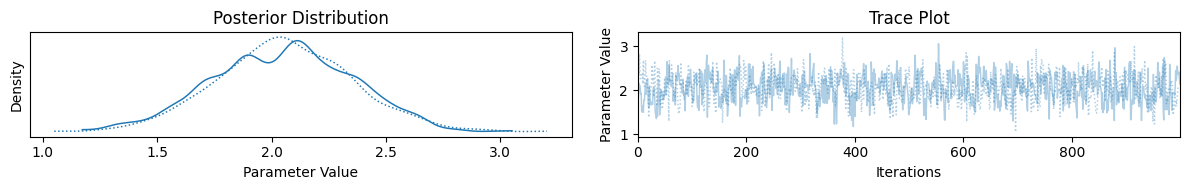

'\n1 bell-shaped\nx-value at the highest point of the solid line is the best estimate.\n\n2\nGood Convergence: wiggly.\nBad Convergence: clear trends\n\nWhy wiggly?\nWhen MCMC finds the best/optimal value, it starts to fluctuate around it.\n'

In [ ]:
pm.plot_trace(trace)

plt.subplot(1, 2, 1)
plt.xlabel("Parameter Value")
plt.ylabel("Density")
plt.title("Posterior Distribution")

plt.subplot(1, 2, 2)
plt.xlabel("Iterations")
plt.ylabel("Parameter Value")
plt.title("Trace Plot")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


#Solid line is Posterior Density Estimation.
#Dotted line is smoothed version.

"""
1 bell-shaped
x-value at the highest point of the solid line is the best estimate.

2
Good Convergence: wiggly.
Bad Convergence: clear trends

Why wiggly?
When MCMC finds the best/optimal value, it starts to fluctuate around it.
"""

### Derivation of the Posterior for $\mu$ and $\sigma^2$

Given the setup:

1. **Prior for \( $\mu$ \)**:  
   $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$

2. **Likelihood (data)**:  
   $ x_1, x_2, \dots, x_n \sim \mathcal{N}(\mu, \sigma^2)$

3. **Posterior (using Bayes' theorem)**:  
   The posterior distribution is proportional to the product of the likelihood $p(\text{data} | \mu, \sigma^2)$ and the prior $p(\mu)$:
   $$
   p(\mu, \sigma^2 | \text{data}) \propto p(\text{data} | \mu, \sigma^2) p(\mu)
   $$

According to the question, the variance $\sigma^2$ is known, but we are interested in the posterior of $\mu$ and $\sigma^2$. We can compute the posterior for $\mu$ and $\sigma^2$ using the **conjugate prior** properties.

---

### Derivation of the Posterior for $\mu$

The posterior distribution for $\mu$ given the data is derived by combining the likelihood and prior.

- **Likelihood (Normal with variance $\sigma^2$)**:  
  $$
  p(\text{data} | \mu, \sigma^2) = \prod_{i=1}^n \mathcal{N}(x_i; \mu, \sigma^2)
  $$
  The likelihood for \( n \) observations is given by:
  $$
  p(\text{data} | \mu, \sigma^2) = \left( \frac{1}{\sqrt{2 \pi \sigma^2}} \right)^n \exp\left( -\frac{1}{2 \sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \right)
  $$

- **Prior for $\mu$**:  
  $$
  p(\mu) = \frac{1}{\sqrt{2 \pi \sigma_0^2}} \exp\left( -\frac{1}{2 \sigma_0^2} (\mu - \mu_0)^2 \right)
  $$

Thus, the posterior distribution is proportional to:
$$
p(\mu | \text{data}) \propto p(\text{data} | \mu, \sigma^2) p(\mu)
$$
Combining the likelihood and prior:
$$
p(\mu | \text{data}) \propto \exp\left( -\frac{1}{2 \sigma^2} \sum_{i=1}^n (x_i - \mu)^2 - \frac{1}{2 \sigma_0^2} (\mu - \mu_0)^2 \right)
$$

To simplify, we complete the square on the terms inside the exponential. The result is a Normal distribution for $\mu$:

$$
\mu | \text{data} \sim \mathcal{N}\left( \frac{ \sum_{i=1}^n x_i / \sigma^2 + \mu_0 / \sigma_0^2 }{n / \sigma^2 + 1 / \sigma_0^2}, \frac{1}{n / \sigma^2 + 1 / \sigma_0^2} \right)
$$

Thus, the posterior mean of $\mu$ is:
$$
\mu_{\text{post}} = \frac{\sum_{i=1}^n x_i / \sigma^2 + \mu_0 / \sigma_0^2}{n / \sigma^2 + 1 / \sigma_0^2}
$$

And the posterior variance of $\mu$ is:
$$
\sigma^2_{\mu_{\text{post}}} = \frac{1}{n / \sigma^2 + 1 / \sigma_0^2}
$$


In [ ]:
# Analytical posterior calculation
def analytical_posterior(data, mu0, sigma0_squared, known_variance):
    n = len(data)
    data_mean = np.mean(data)

    posterior_variance = 1 / (n / known_variance + 1 / sigma0_squared)
    posterior_mean = posterior_variance * (data_mean * n / known_variance + mu0 / sigma0_squared)

    return posterior_mean, posterior_variance

posterior_mean, posterior_variance = analytical_posterior(data, mu0, sigma0_squared, mle_variance)
print(f"Analytical Posterior Mean: {posterior_mean}, Variance: {posterior_variance}")


Analytical Posterior Mean: 2.051196373609802, Variance: 0.0841922207873168


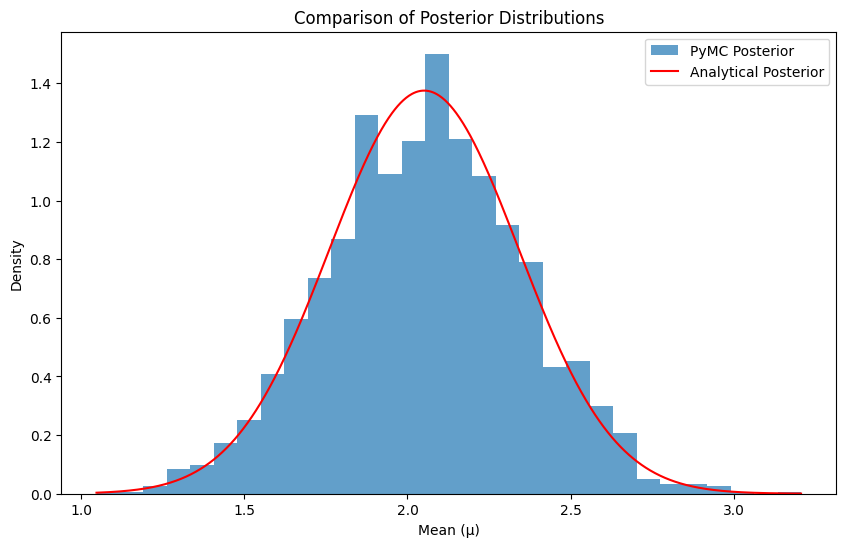

In [ ]:
# Compare posterior distributions
# Plot PyMC posterior
pm_posterior_samples = trace.posterior["mu"].values.flatten()
plt.figure(figsize=(10, 6))
plt.hist(pm_posterior_samples, bins=30, density=True, alpha=0.7, label="PyMC Posterior")

# Plot Analytical Posterior
x = np.linspace(min(pm_posterior_samples), max(pm_posterior_samples), 1000)
# probability density function (PDF) of a normal distribution
plt.plot(x, norm.pdf(x, loc=posterior_mean, scale=np.sqrt(posterior_variance)),
         label="Analytical Posterior", color="red")


plt.title("Comparison of Posterior Distributions")
plt.xlabel("Mean (\u03BC)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
## Question 2
from google.colab import drive #This is only for the use of Google Colab.
drive.mount('/content/drive')
y = np.loadtxt('/your path/Prussian-Horse-Kick-Data_Workshop.csv')#Upload your file to Google drive and read the data
# Part (a): Estimate mean and variance by maximizing likelihood
# TODO your function

# Part (b): Estimate posterior distribution using PyMC
alpha, beta= #TODO

with pm.Model() as model:
    lam = #TODO pm.Gamma() # Prior on lambda
    Y_obs = # TODO Poisson in PyMC #Likelihood
    trace = # TODO pm.sample()

### Likelihood
$p(\mathbf{y}|\lambda) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda)$ <br>
### Prior
$p(\lambda) \propto \lambda^{\alpha-1} \exp(-\beta \lambda)$ <br>
### Posterior
$p(\lambda|\mathbf{y}) \propto (\mathbf{y}|\lambda) p(\lambda)$ <br>
$p(\lambda|\mathbf{y}) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda) \lambda^{\alpha-1} \exp(-\beta \lambda)$ <br>
$p(\lambda|\mathbf{y}) \lambda^{\sum_{i=1}^ny_i+\alpha-1} \exp(-\lambda(\beta+n))$ <br>
$\lambda \sim \text{Gamma}(\sum_{i=1}^ny_i+\alpha,\beta+n)$